# Basic Synthetic Generation using Diffusion
To see how a diffusion model canbe trained to create synthetic data, we generate a two dimensional dataset that has 8 disk like clusters around a circle centered at the origin. We will then train a diffusion to be able to generate synthetic data.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from synthetic_generation.diffusion.models import DiffusionNet
from synthetic_generation.diffusion.process import DiffusionProcess
from synthetic_generation.diffusion.schedules import linear_beta_schedule

In [2]:
def make_gaussian_mixture(
    n_samples=50_000,
    centers=8,
    radius=5.0,
    std=0.5,
    seed=0
):
    """
    Parameters
    ----------
    n_samples : int
        number of samples
    centers : int 
        number of disk clusters
    radius : float
        radius of ring containing centers of the clusters
    std : float
        standard deviation for distance from center of disk for a point
    seed : int
        random seed to use
    Returns
    -------
    tuple
        array of sample points, array of cluster centers for each point, array of labels for each cluster
    """
    rng = np.random.default_rng(seed)
    # compute the centers of each cluster
    angles = np.linspace(0, 2*np.pi, centers, endpoint=False)
    means = np.stack([
        radius * np.cos(angles),
        radius * np.sin(angles)
    ], axis=1)

    samples = []
    sample_labels = []
    sample_centers = []
    # choose a random center and a random point in the cluster
    for _ in range(n_samples):
        k = rng.integers(0, centers)
        # add the center and label
        sample_labels.append(k)
        sample_centers.append(means[k])
        x = rng.normal(loc=means[k], scale=std, size=2)
        samples.append(x)

    return np.array(samples, dtype=np.float32), np.array(sample_labels), np.array(sample_centers,dtype=np.float32)

In [3]:
X_gauss, labels, centers = make_gaussian_mixture()

#### Training the model
We create a simple DiffusionNet model and then use the DiffusionProcess with that model to train on the data

In [4]:
# set seed for reproducibility
torch.manual_seed(42)

In [5]:
DenoiseNet = DiffusionNet(data_dim=2, num_hidden_layers=4,  hidden_dims=(256,256))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DenoiseNet.to(device)


In [6]:
# turn the data into a tensor and move to device
X_train = torch.Tensor(X_gauss).to(device)

In [7]:
diffusion_process = DiffusionProcess(
    model = model,
    num_timesteps = model.time_embedding.num_timesteps,
    betas=linear_beta_schedule(num_timesteps=model.time_embedding.num_timesteps)
)

In [8]:
diffusion_process.train(X=X_train)

Diffusion training:   0%|          | 0/100 [00:00<?, ?it/s]

#### Visualization
We now create synthetic data from the process and look at a scatterplot to compare it to the real data.


In [9]:
# get a random sample of points from the true data to plot
sample_size = 10000
idx = np.random.default_rng(42).choice(len(X_gauss), size=sample_size, replace=False)
X_sample = X_gauss[idx]

In [10]:
X_fake = diffusion_process.generate_samples(num_samples=sample_size)

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

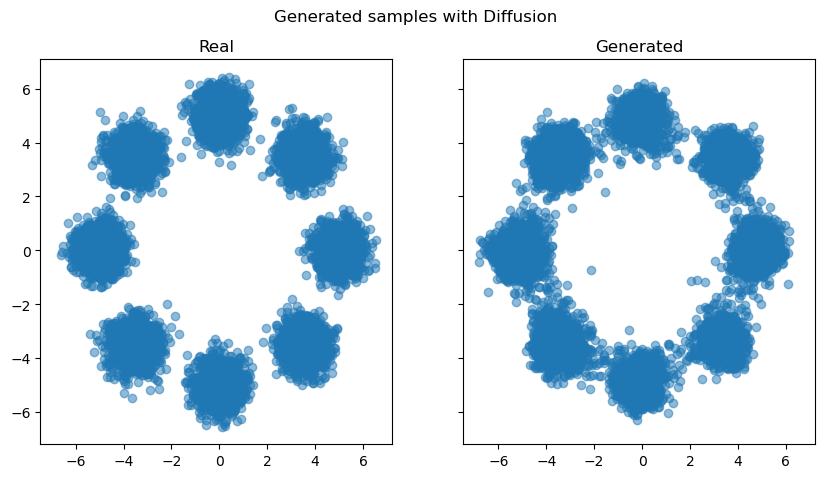

In [11]:
fig, axs = plt.subplots(1, 2, figsize = (10,5), sharex=True, sharey=True)
axs[0].scatter(X_sample[:, 0], X_sample[:, 1], alpha=0.5)
axs[0].set_title("Real")
axs[1].scatter(X_fake[:, 0], X_fake[:, 1], alpha=0.5)
axs[1].set_title("Generated")
fig.suptitle("Generated samples with Diffusion")
plt.show()

We can see that we get pretty decent coverage of the ring (significantly better than we saw with vanilla GAN)
Next, we try a faster version using DDIM with 50 inference steps.

In [12]:
X_fake_ddim = diffusion_process.generate_samples_ddim(
    num_samples=sample_size,
    num_inference_steps=50,
    )

DDIM Sampling (50 steps):   0%|          | 0/50 [00:00<?, ?it/s]

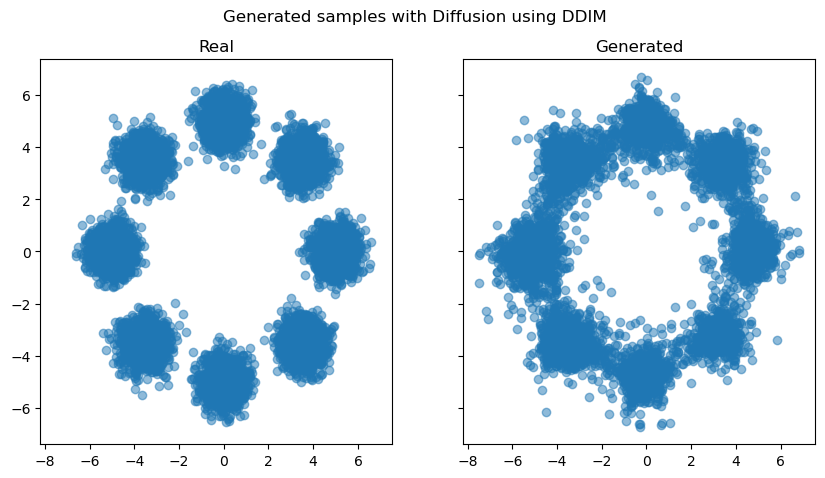

In [13]:
fig, axs = plt.subplots(1, 2, figsize = (10,5), sharex=True, sharey=True)
axs[0].scatter(X_sample[:, 0], X_sample[:, 1], alpha=0.5)
axs[0].set_title("Real")
axs[1].scatter(X_fake_ddim[:, 0], X_fake_ddim[:, 1], alpha=0.5)
axs[1].set_title("Generated")
fig.suptitle("Generated samples with Diffusion using DDIM")
plt.show()

We can see that DDIM produce a sample not quite as good as before, however the full set of timesteps took 47 seconds compared to only 2s for DDIM. For this sort of time frame, it's not an issue, but for a large number of samples or a more complicated network, DDIM can save time while getting close in quality.